## Heart Disease Prediction


| #   | Feature    | Full Name                   | Type        | Description / Values                                                                            |
| --- | ---------- | --------------------------- | ----------- | ----------------------------------------------------------------------------------------------- |
| 1   | `age`      | Age                         | Numeric     | Age of the patient in years.                                                                    |
| 2   | `sex`      | Sex                         | Binary      | `1` = Male, `0` = Female                                                                        |
| 3   | `cp`       | Chest Pain Type             | Categorical | `1` = Typical angina, `2` = Atypical angina, `3` = Non-anginal pain, `4` = Asymptomatic         |
| 4   | `trestbps` | Resting Blood Pressure      | Numeric     | Resting blood pressure (mm Hg) on hospital admission.                                           |
| 5   | `chol`     | Serum Cholesterol           | Numeric     | Serum cholesterol in mg/dl.                                                                     |
| 6   | `fbs`      | Fasting Blood Sugar         | Binary      | Fasting blood sugar > 120 mg/dl. `1` = True, `0` = False                                        |
| 7   | `restecg`  | Resting ECG Results         | Categorical | `0` = Normal, `1` = ST-T wave abnormality, `2` = Left ventricular hypertrophy (Estes' criteria) |
| 8   | `thalach`  | Maximum Heart Rate          | Numeric     | Maximum heart rate achieved during exercise.                                                    |
| 9   | `exang`    | Exercise Induced Angina     | Binary      | `1` = Yes, `0` = No                                                                             |
| 10  | `oldpeak`  | ST Depression               | Numeric     | ST depression induced by exercise relative to rest.                                             |
| 11  | `slope`    | Slope of Peak ST Segment    | Categorical | `1` = Upsloping, `2` = Flat, `3` = Downsloping                                                  |
| 12  | `ca`       | Major Vessels (Fluoroscopy) | Numeric     | Number of major vessels (0–3) colored by fluoroscopy.                                           |
| 13  | `thal`     | Thalassemia                 | Categorical | `3` = Normal, `6` = Fixed defect, `7` = Reversible defect                                       |
| 14  | `num` ⭐   | Target                      | Binary      | `0` = <50% diameter narrowing, `1` = >50% diameter narrowing                                    |


In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

In [95]:
df = pd.read_csv("./heart-disease.csv")

df.shape

(303, 14)

## EDA


In [96]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [97]:
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

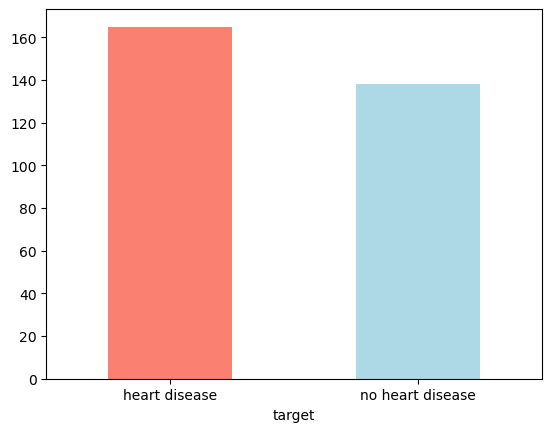

In [98]:
df["target"].value_counts().plot(
    kind="bar",
    color=["salmon", "lightblue"],
)
plt.xticks(ticks=[0, 1], labels=["heart disease", "no heart disease"], rotation=0)
plt.show()

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [100]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [101]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [102]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [103]:
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


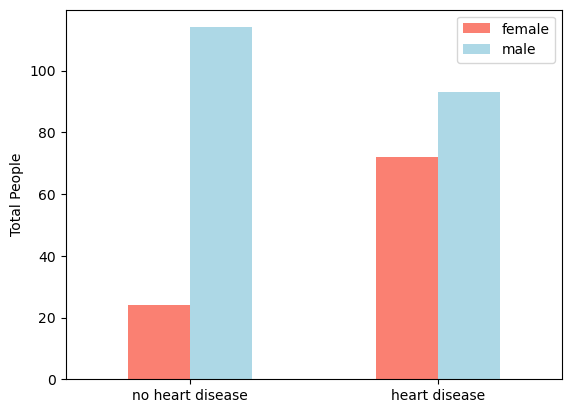

In [104]:
pd.crosstab(df.target, df.sex).plot(
    kind="bar",
    color=["salmon", "lightblue"],
)

plt.legend(["female", "male"])
plt.xticks(ticks=[0, 1], labels=["no heart disease", "heart disease"], rotation=0)
plt.xlabel("")
plt.ylabel("Total People")
plt.show()

In [105]:
df["thalach"].value_counts()

thalach
162    11
160     9
163     9
152     8
173     8
       ..
202     1
184     1
121     1
192     1
90      1
Name: count, Length: 91, dtype: int64

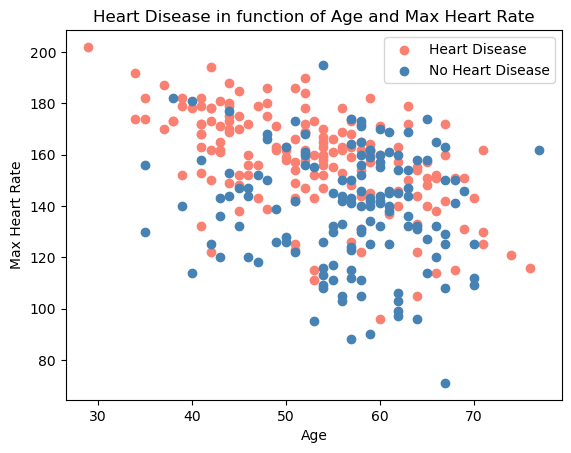

In [106]:
# age vs max_heart_rate (thalach)
plt.scatter(
    df.age[df.target == 1],
    df.thalach[df.target == 1],
    color="salmon",
    label="Heart Disease",
)

plt.scatter(
    df.age[df.target == 0],
    df.thalach[df.target == 0],
    color="steelblue",
    label="No Heart Disease",
)

plt.legend()
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.show()

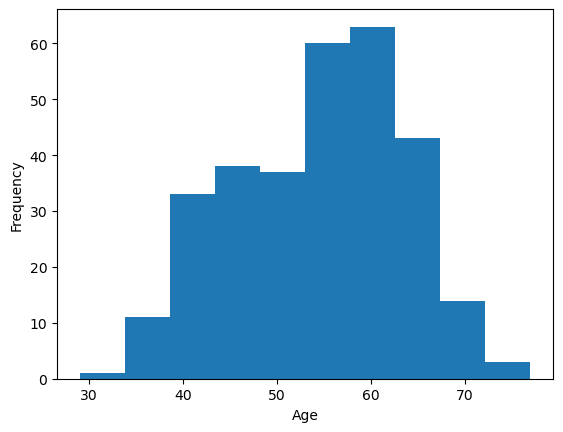

In [107]:
df.age.plot.hist()

plt.xlabel("Age")
plt.show()

### 3. `cp` — Chest Pain Type

- _Type:_ Categorical
- _Values:_ `1` = Typical angina, `2` = Atypical angina, `3` = Non-anginal pain, `4` = Asymptomatic


In [108]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


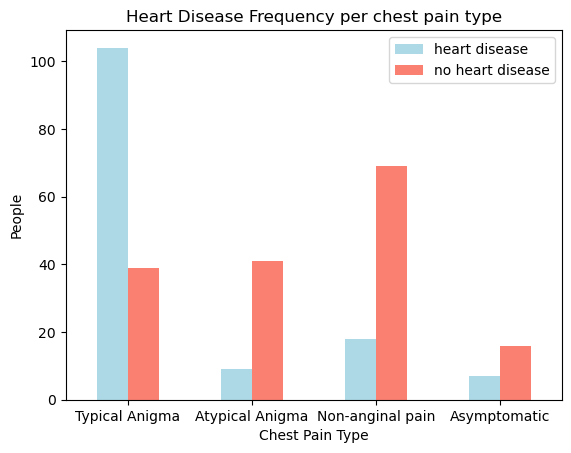

In [109]:
pd.crosstab(df.cp, df.target).plot(kind="bar", color=["lightblue", "salmon"])

plt.title("Heart Disease Frequency per chest pain type")
plt.legend(["heart disease", "no heart disease"])
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=["Typical Anigma", "Atypical Anigma", "Non-anginal pain", "Asymptomatic"],
    rotation=0,
)
plt.xlabel("Chest Pain Type")
plt.ylabel("People")
plt.show()

In [110]:
# make correlation matrix
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


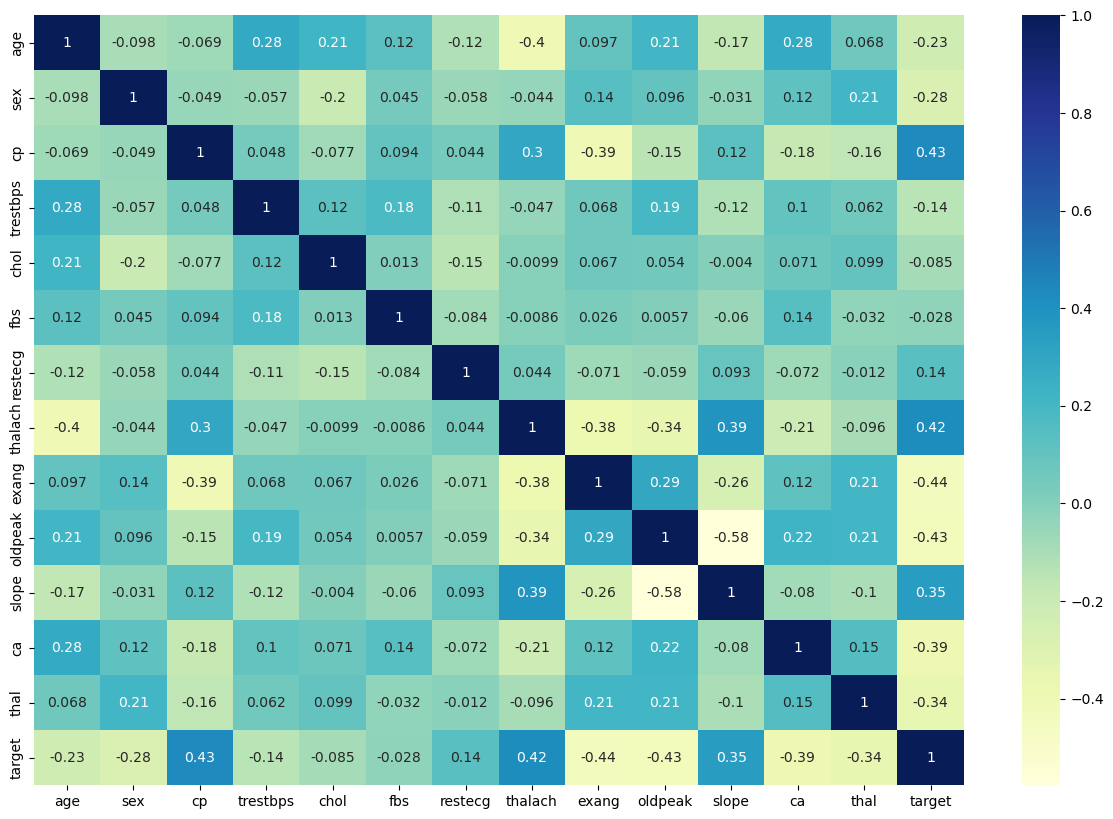

In [111]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, cmap="YlGnBu")
plt.show()

## Modeling


In [112]:
X = df.drop("target", axis=1)
y = df["target"]

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [114]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((242, 13), (242,), (61, 13), (61,))

In [115]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
}

In [116]:
def fit_and_score(models, X_train, X_test, y_train, y_test):
    np.random.seed(42)
    model_scores = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        model_scores[name] = model.score(X_test, y_test)

    return model_scores

In [117]:
model_scores = fit_and_score(models, X_train, X_test, y_train, y_test)

model_scores

{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

## Hyper Parameters Tuning


In [118]:
log_reg_grid = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["lbfgs", "liblinear", "newton-cg", "sag", "saga"],
    "penalty": ["l1", "l2", "elasticnet", None],
    "max_iter": [100, 200, 500, 1000],
    "class_weight": ["balanced", None],
}

rf_grid = {
    "n_estimators": np.arange(100, 1001, 100),
    "max_depth": [None, 3, 5, 10, 20, 30],
    "min_samples_split": np.arange(2, 21, 2),
    "min_samples_leaf": np.arange(1, 21, 2),
    "max_features": ["sqrt", "log2", None],
    "max_samples": [0.5, 0.7, 0.9, None],
    "bootstrap": [True, False],
    "criterion": ["gini", "entropy", "log_loss"],
    "class_weight": ["balanced", "balanced_subsample", None],
}

In [119]:
models_dicts = [
    {
        "name": "Logistic Regression",
        "model": LogisticRegression(),
        "params": log_reg_grid,
    },
    {
        "name": "Random Forest",
        "model": RandomForestClassifier(),
        "params": rf_grid,
    },
]

In [120]:
def hyperparamtuner(model_dicts):
    np.random.seed(42)
    for model_dict in model_dicts:
        rsv_clf = RandomizedSearchCV(
            model_dict["model"],
            model_dict["params"],
            cv=5,
            n_iter=20,
            verbose=True,
        )
        rsv_clf.fit(X_train, y_train)
        print(model_dict["name"] + ": ", rsv_clf.best_params_)

In [121]:
hyperparamtuner(model_dicts=models_dicts)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Logistic Regression:  {'solver': 'lbfgs', 'penalty': None, 'max_iter': 500, 'class_weight': None, 'C': 0.03359818286283781}
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Random Forest:  {'n_estimators': 900, 'min_samples_split': 2, 'min_samples_leaf': 11, 'max_samples': 0.5, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'gini', 'class_weight': 'balanced_subsample', 'bootstrap': True}


In [122]:
models = {
    "Logistic Regression": LogisticRegression(
        solver="lbfgs",
        penalty=None,
        max_iter=500,
        class_weight=None,
        C=0.033598,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=900,
        min_samples_split=2,
        min_samples_leaf=11,
        max_samples=0.5,
        max_features="log2",
        max_depth=10,
        criterion="gini",
        class_weight="balanced_subsample",
        bootstrap=True,
    ),
}

In [123]:
model_scores = fit_and_score(models, X_train, X_test, y_train, y_test)

model_scores

{'Logistic Regression': 0.8688524590163934,
 'Random Forest': 0.9016393442622951}

### Evaluating our tuned machine learning classifier and Choosing the best model

- ROC curve and ROC score
- Confusion Matrix
- Classification Report
- Precision
- Recall
- F1-Score


In [124]:
rf_clf = RandomForestClassifier(
    n_estimators=900,
    min_samples_split=2,
    min_samples_leaf=11,
    max_samples=0.5,
    max_features="log2",
    max_depth=10,
    criterion="gini",
    class_weight="balanced_subsample",
    bootstrap=True,
)

rf_clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                       max_features='log2', max_samples=0.5,
                       min_samples_leaf=11, n_estimators=900)

In [125]:
y_preds = rf_clf.predict(X_test)
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

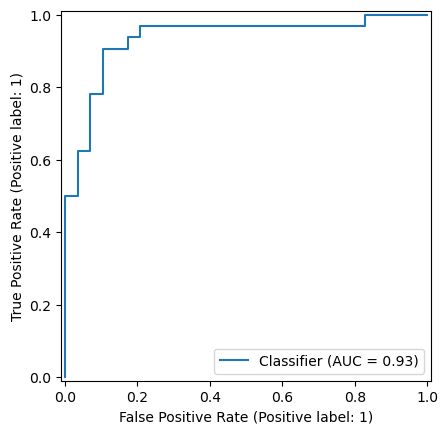

In [126]:
RocCurveDisplay.from_predictions(y_test, rf_clf.predict_proba(X_test)[:, 1])

plt.show()

In [127]:
# confusion matrix
confusion_matrix(y_test, y_preds)

array([[26,  3],
       [ 3, 29]], dtype=int64)

In [128]:
def plot_conf_mat(y_test, y_preds):
    _, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(
        confusion_matrix(y_test, y_preds),
        annot=True,
        cbar=False,
        cmap="YlGnBu",
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

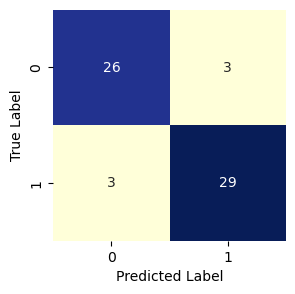

In [129]:
plot_conf_mat(y_test, y_preds)

In [130]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        29
           1       0.91      0.91      0.91        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



## Cross Validation


In [131]:
rf_clf = RandomForestClassifier(
    n_estimators=900,
    min_samples_split=2,
    min_samples_leaf=11,
    max_samples=0.5,
    max_features="log2",
    max_depth=10,
    criterion="gini",
    class_weight="balanced_subsample",
    bootstrap=True,
)

In [132]:
cv_acc_scores = cross_val_score(rf_clf, X, y, cv=5, scoring="accuracy")

accuracy = np.mean(cv_acc_scores)

cv_acc_scores, accuracy

(array([0.81967213, 0.8852459 , 0.81967213, 0.86666667, 0.76666667]),
 0.831584699453552)

In [133]:
cv_acc_scores = cross_val_score(rf_clf, X, y, cv=5, scoring="precision")

precision = np.mean(cv_acc_scores)

cv_acc_scores, precision

(array([0.80555556, 0.90909091, 0.83870968, 0.88235294, 0.77142857]),
 0.8414275309341723)

In [134]:
cv_acc_scores = cross_val_score(rf_clf, X, y, cv=5, scoring="recall")

recall = np.mean(cv_acc_scores)

cv_acc_scores, recall

(array([0.87878788, 0.87878788, 0.78787879, 0.87878788, 0.81818182]),
 0.8484848484848484)

In [135]:
cv_acc_scores = cross_val_score(rf_clf, X, y, cv=5, scoring="f1")

f1 = np.mean(cv_acc_scores)

cv_acc_scores, f1

(array([0.84057971, 0.90909091, 0.8125    , 0.89552239, 0.79411765]),
 0.8503621308708723)

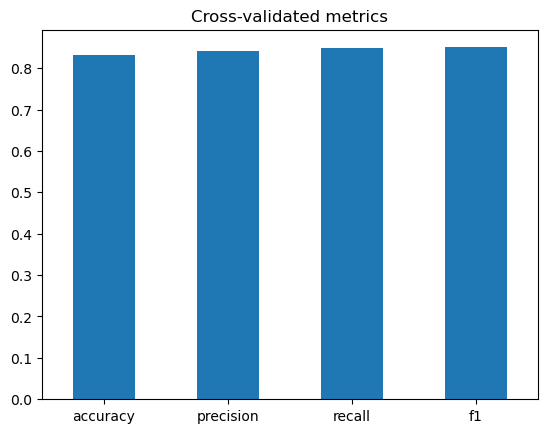

In [136]:
cv_metrics = pd.DataFrame(
    {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    },
    index=[0],
)

cv_metrics.T.plot.bar(title="Cross-validated metrics", legend=False)
plt.xticks(rotation=0)
plt.show()

## Feature Importance


In [137]:
rf_clf.fit(X_train, y_train)
importances = rf_clf.feature_importances_

In [141]:
feature_dict = dict(zip(df.columns[:-1], importances))

feature_dict

{'age': 0.060054405326572885,
 'sex': 0.038595344860056766,
 'cp': 0.14565303711723693,
 'trestbps': 0.01811177023912291,
 'chol': 0.02421407983080744,
 'fbs': 0.0002884686620436104,
 'restecg': 0.007927674601224038,
 'thalach': 0.10041363777996,
 'exang': 0.10085264570016284,
 'oldpeak': 0.12610477106905632,
 'slope': 0.06624445485073048,
 'ca': 0.1745910987419724,
 'thal': 0.1369486112210534}

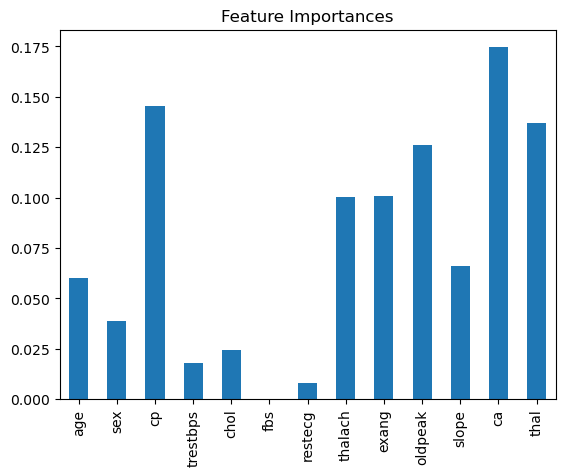

In [149]:
feature_df = pd.DataFrame(feature_dict, index=[0])

feature_df.T.plot.bar(title="Feature Importances", legend=False)

plt.show()